Hoàng Ngọc Dung - 23139006

In [231]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

In [232]:
df = pd.read_csv("clean_feature.csv")
df["datetime"] = pd.to_datetime(df["Day"]) + pd.to_timedelta(df["hour"], unit="h")
print(pd.Series(df["ServiceID"].unique()).sort_values().to_list())

print(df["ServiceID"].unique().shape)  
df

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
(12,)


,Day,DoWeek,hour,count,passed,period,data,ServiceID,datetime
0,2021-12-29,2,17,2974,2974,63.952589,612.081036,2,2021-12-29 17:00:00
1,2021-12-29,2,17,4528,4528,63.000000,960.307862,11,2021-12-29 17:00:00
2,2021-12-29,2,17,19,19,62.000000,566.315789,5,2021-12-29 17:00:00
3,2021-12-29,2,17,1207,1207,63.000000,601.025684,7,2021-12-29 17:00:00
4,2021-12-29,2,18,8450,8450,63.942130,611.024024,2,2021-12-29 18:00:00
...,...,...,...,...,...,...,...,...,...
450666,2023-07-24,0,18,1,1,62.000000,624.000000,1,2023-07-24 18:00:00
450667,2023-07-24,0,18,108,108,62.000000,1075.972222,5,2023-07-24 18:00:00
450668,2023-07-24,0,18,5279,5279,63.000000,599.900170,7,2023-07-24 18:00:00
450669,2023-07-24,0,18,2,2,63.000000,1437.500000,0,2023-07-24 18:00:00


In [233]:
# a = df[(df["datetime"].dt.year == 2023) & (df["datetime"].dt.month == 6)]
# a
# df = df.set_index("datetime")
# df = df.sort_index()
# # query theo tháng/năm
# a = df.loc["2023-05":"2023-06"]
# print(a.shape)
# print(a.head())


In [234]:
def query(df, t_datetime, months=0, years=0, days=0, hours=0):
    t = pd.to_datetime(t_datetime)
    
    offset = pd.DateOffset(years=years, months=months)
    td = pd.Timedelta(days=days, hours=hours)
    start = t - offset - td
    
    #[t - delta_t, t]
    mask = (df["datetime"] >= start) & (df["datetime"] <= t)
    return df.loc[mask]

In [235]:
t = "2023-07-24 18:00:00"
result = query(df, t, years=0, months=4, days=3, hours=5)
result = result.sort_index()
result

,Day,DoWeek,hour,count,passed,period,data,ServiceID,datetime
80342,2023-03-21,1,13,8919,8919,63.928019,642.264043,2,2023-03-21 13:00:00
80343,2023-03-21,1,13,2,2,62.000000,514.000000,6,2023-03-21 13:00:00
80344,2023-03-21,1,13,11793,11793,63.000000,928.704655,11,2023-03-21 13:00:00
80345,2023-03-21,1,13,45,45,62.000000,570.066667,1,2023-03-21 13:00:00
80346,2023-03-21,1,13,161,161,62.000000,2606.242236,5,2023-03-21 13:00:00
...,...,...,...,...,...,...,...,...,...
450666,2023-07-24,0,18,1,1,62.000000,624.000000,1,2023-07-24 18:00:00
450667,2023-07-24,0,18,108,108,62.000000,1075.972222,5,2023-07-24 18:00:00
450668,2023-07-24,0,18,5279,5279,63.000000,599.900170,7,2023-07-24 18:00:00
450669,2023-07-24,0,18,2,2,63.000000,1437.500000,0,2023-07-24 18:00:00


In [236]:
a = result.groupby("ServiceID")["count"].mean()
a

ServiceID
0        2.388535
1       45.803245
2     6389.176428
3        1.056417
4        1.611187
5       95.117510
6        1.588781
7     3265.645733
8        3.888476
9        3.489565
10      19.074913
11    8561.513490
Name: count, dtype: float64

In [237]:
# Rút trích đặc trưng trong khoảng [t - delta_t, t]
features = (
    result.groupby(["datetime", "ServiceID"])
        .agg(
        mean_count=("count", "mean"),
        mean_pass =("passed", "mean"),
        mean_data =("data", "mean"),
        time      =("period", "count")  
        )
)

matrix = (
    features.unstack(level="ServiceID", fill_value=0)
            .sort_index(axis=1, level=1)   
)

matrix["DoW"] = matrix.index.dayofweek
matrix["HiD"] = matrix.index.hour

matrix


,mean_count,mean_data,mean_pass,time,mean_count,mean_data,mean_pass,time,mean_count,mean_data,...,mean_count,mean_data,mean_pass,time,mean_count,mean_data,mean_pass,time,DoW,HiD
ServiceID,0,0,0,0,1,1,1,1,2,2,...,10,10,10,10,11,11,11,11,,
datetime,,,,,,,,,,,,,,,,,,,,,
2023-03-21 13:00:00,2.000000,1567.000000,2.000000,2,53.250,553.652742,53.125,8,7388.750,651.704165,...,0.000000,0.000000,0.000000,0,9686.625000,933.111476,9686.625000,8,1,13
2023-03-21 14:00:00,2.666667,1711.616667,2.666667,6,67.500,545.103398,67.500,8,8854.875,658.005302,...,0.000000,0.000000,0.000000,0,11443.000000,939.370916,11443.000000,8,1,14
2023-03-21 15:00:00,2.000000,1644.875000,2.000000,8,90.875,540.656615,90.875,8,9362.250,658.010186,...,0.000000,0.000000,0.000000,0,12304.750000,952.571362,12304.750000,8,1,15
2023-03-21 16:00:00,2.200000,1486.400000,2.200000,5,58.000,549.337090,58.000,8,9061.875,655.782393,...,0.000000,0.000000,0.000000,0,11859.375000,947.565795,11859.375000,8,1,16
2023-03-21 17:00:00,1.375000,1409.041667,1.375000,8,8.300,529.749691,8.300,10,8723.250,655.932042,...,0.000000,0.000000,0.000000,0,11227.250000,934.175880,11227.250000,12,1,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-07-24 14:00:00,6.250000,1604.770833,6.250000,4,87.625,561.074241,87.625,8,8992.750,660.691365,...,15.000000,378251.423480,15.000000,8,11757.250000,945.996360,11757.250000,8,0,14
2023-07-24 15:00:00,3.125000,1706.733333,3.125000,8,83.500,559.099741,83.500,8,9461.000,652.613439,...,15.000000,378251.791223,15.000000,8,12506.500000,951.279353,12506.500000,8,0,15


In [238]:
# tổng theo cột (dọc theo hàng) → axis=0
# tổng theo hàng (ngang theo cột) → axis=1
matrix["label"] = (matrix["mean_count"] == matrix["mean_pass"]).all(axis=1).astype(int)
print(matrix[("label")].value_counts())

matrix

label
1    2051
0     955
Name: count, dtype: int64


mean_count    mean_data mean_pass time mean_count  \
ServiceID                    0            0         0    0          1   
datetime                                                                
2023-03-21 13:00:00   2.000000  1567.000000  2.000000    2     53.250   
2023-03-21 14:00:00   2.666667  1711.616667  2.666667    6     67.500   
2023-03-21 15:00:00   2.000000  1644.875000  2.000000    8     90.875   
2023-03-21 16:00:00   2.200000  1486.400000  2.200000    5     58.000   
2023-03-21 17:00:00   1.375000  1409.041667  1.375000    8      8.300   
...                        ...          ...       ...  ...        ...   
2023-07-24 14:00:00   6.250000  1604.770833  6.250000    4     87.625   
2023-07-24 15:00:00   3.125000  1706.733333  3.125000    8     83.500   
2023-07-24 16:00:00   2.571429  1408.761905  2.571429    7     62.625   
2023-07-24 17:00:00   1.000000  2202.000000  1.000000    1      8.500   
2023-07-24 18:00:00   1.333333  1583.500000  1.333333    3      2.625   

                      mean_data mean_pass time mean_count   mean_data  ...  \
ServiceID                     1         1    1          2           2  ...   
datetime                                                               ...   
2023-03-21 13:00:00  553.652742    53.125    8   7388.750  651.704165  ...   
2023-03-21 14:00:00  545.103398    67.500    8   8854.875  658.005302  ...   
2023-03-21 15:00:00  540.656615    90.875    8   9362.250  658.010186  ...   
2023-03-21 16:00:00  549.337090    58.000    8   9061.875  655.782393  ...   
2023-03-21 17:00:00  529.749691     8.300   10   8723.250  655.932042  ...   
...                         ...       ...  ...        ...         ...  ...   
2023-07-24 14:00:00  561.074241    87.625    8   8992.750  660.691365  ...   
2023-07-24 15:00:00  559.099741    83.500    8   9461.000  652.613439  ...   
2023-07-24 16:00:00  587.271777    62.625    8   9103.000  640.012532  ...   
2023-07-24 17:00:00  605.101780     8.500    8   8451.250  641.604435  ...   
2023-07-24 18:00:00  625.552083     2.625    8   9979.800  634.672423  ...   

                                    mean_pass time    mean_count   mean_data  \
ServiceID                       10         10   10            11          11   
datetime                                                                       
2023-03-21 13:00:00       0.000000   0.000000    0   9686.625000  933.111476   
2023-03-21 14:00:00       0.000000   0.000000    0  11443.000000  939.370916   
2023-03-21 15:00:00       0.000000   0.000000    0  12304.750000  952.571362   
2023-03-21 16:00:00       0.000000   0.000000    0  11859.375000  947.565795   
2023-03-21 17:00:00       0.000000   0.000000    0  11227.250000  934.175880   
...                            ...        ...  ...           ...         ...   
2023-07-24 14:00:00  378251.423480  15.000000    8  11757.250000  945.996360   
2023-07-24 15:00:00  378251.791223  15.000000    8  12506.500000  951.279353   
2023-07-24 16:00:00  378251.514512  15.000000    8  11957.750000  943.866314   
2023-07-24 17:00:00  378251.973496  15.416667   12  10919.833333  930.734457   
2023-07-24 18:00:00  378251.912747  19.200000   10  12427.200000  916.993728   

                        mean_pass time DoW HiD label  
ServiceID                      11   11                
datetime                                              
2023-03-21 13:00:00   9686.625000    8   1  13     0  
2023-03-21 14:00:00  11443.000000    8   1  14     1  
2023-03-21 15:00:00  12304.750000    8   1  15     1  
2023-03-21 16:00:00  11859.375000    8   1  16     1  
2023-03-21 17:00:00  11227.250000   12   1  17     1  
...                           ...  ...  ..  ..   ...  
2023-07-24 14:00:00  11757.250000    8   0  14     1  
2023-07-24 15:00:00  12506.500000    8   0  15     0  
2023-07-24 16:00:00  11957.750000    8   0  16     1  
2023-07-24 17:00:00  10919.833333   12   0  17     0  
2023-07-24 18:00:00  12427.200000   10   0  18     0  

[3006 rows x

In [239]:
def future_label(df, hours):
    df["datetime"] = pd.to_datetime(df["datetime"])
    df["error"] = (df["count"] != df["passed"]).astype(int)
    err_by_t = df.groupby("datetime")["error"].max().sort_index()

    future_label = (
        (err_by_t.shift(-1).fillna(0).astype(int)) |
        (err_by_t.shift(-2).fillna(0).astype(int))
    ).astype(int)

    return future_label.rename("label")


In [240]:
matrix["future"] =  future_label(result, 2)
matrix.drop_duplicates()
matrix

,mean_count,mean_data,mean_pass,time,mean_count,mean_data,mean_pass,time,mean_count,mean_data,...,mean_pass,time,mean_count,mean_data,mean_pass,time,DoW,HiD,label,future
ServiceID,0,0,0,0,1,1,1,1,2,2,...,10,10,11,11,11,11,,,,
datetime,,,,,,,,,,,,,,,,,,,,,
2023-03-21 13:00:00,2.000000,1567.000000,2.000000,2,53.250,553.652742,53.125,8,7388.750,651.704165,...,0.000000,0,9686.625000,933.111476,9686.625000,8,1,13,0,0
2023-03-21 14:00:00,2.666667,1711.616667,2.666667,6,67.500,545.103398,67.500,8,8854.875,658.005302,...,0.000000,0,11443.000000,939.370916,11443.000000,8,1,14,1,0
2023-03-21 15:00:00,2.000000,1644.875000,2.000000,8,90.875,540.656615,90.875,8,9362.250,658.010186,...,0.000000,0,12304.750000,952.571362,12304.750000,8,1,15,1,0
2023-03-21 16:00:00,2.200000,1486.400000,2.200000,5,58.000,549.337090,58.000,8,9061.875,655.782393,...,0.000000,0,11859.375000,947.565795,11859.375000,8,1,16,1,1
2023-03-21 17:00:00,1.375000,1409.041667,1.375000,8,8.300,529.749691,8.300,10,8723.250,655.932042,...,0.000000,0,11227.250000,934.175880,11227.250000,12,1,17,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-07-24 14:00:00,6.250000,1604.770833,6.250000,4,87.625,561.074241,87.625,8,8992.750,660.691365,...,15.000000,8,11757.250000,945.996360,11757.250000,8,0,14,1,1
2023-07-24 15:00:00,3.125000,1706.733333,3.125000,8,83.500,559.099741,83.500,8,9461.000,652.613439,...,15.000000,8,12506.500000,951.279353,12506.500000,8,0,15,0,1


In [241]:
start_time = matrix.index.get_level_values("datetime").min()
end_time   = matrix.index.get_level_values("datetime").max()
print(start_time)
print(end_time)

2023-03-21 13:00:00
2023-07-24 18:00:00


In [242]:
matrix.columns = [
    f"{col[0]}_{col[1]}" if isinstance(col, tuple) and col[1] != "" else str(col[0])
    for col in matrix.columns.to_flat_index()
]

print(matrix.shape)
print(matrix.columns[:10])



(3006, 52)
Index(['mean_count_0', 'mean_data_0', 'mean_pass_0', 'time_0', 'mean_count_1',
       'mean_data_1', 'mean_pass_1', 'time_1', 'mean_count_2', 'mean_data_2'],
      dtype='object')


In [243]:
datetimes = matrix.index.get_level_values("datetime")
split_time = end_time - pd.DateOffset(months=3)
train_val = matrix[datetimes <= split_time]
test      = matrix[datetimes >  split_time]

X = train_val.drop(columns=["label", "future"])   
y = train_val["label"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.3,
    shuffle=True,
    random_state=42
)

X_test = test.drop(columns=["label", "future"])
y_test = test["label"]

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)


Train: (575, 50) (575,)
Val:   (247, 50) (247,)
Test:  (2184, 50) (2184,)


In [244]:
class HourToXY(BaseEstimator, TransformerMixin):
    def __init__(self, period=24):
        self.period = period
    def fit(self, X, y=None): return self
    def transform(self, X):
        X = np.asarray(X)
        h = X if X.ndim == 1 else X[:, 0]
        theta = 2*np.pi*h/self.period
        return np.c_[np.cos(theta), np.sin(theta)]
    def get_feature_names_out(self, input_features=None):
        base = input_features[0] if input_features else "hour"
        return np.array([f"{base}_x", f"{base}_y"])

In [245]:
hour_to_xy = HourToXY(period=24)
count = [col for col in matrix.columns if "mean_count" in col]
passed = [col for col in matrix.columns if "mean_pass" in col]
data = [col for col in matrix.columns if "mean_data" in col]
time = [col for col in matrix.columns if "time" in col]
hour = [col for col in matrix.columns if "HiD" in col]
DoW = [col for col in matrix.columns if "DoW" in col]

print("Count & passed cols:", count + passed)
print("Data cols:", data)
print("Time cols:", time)
print("Hour cols:", hour)
print("DoW cols:", DoW)

ct = ColumnTransformer(
        transformers=[
                ("HiD", hour_to_xy, hour),
                ("onehot", OneHotEncoder(handle_unknown="ignore"), count+passed),
                ("data", StandardScaler(), data),
                ("time", MinMaxScaler(), time),
                ("DoW", "passthrough" , DoW) #ko biến đổi
        ],
)

ct

Count & passed cols: ['mean_count_0', 'mean_count_1', 'mean_count_2', 'mean_count_3', 'mean_count_4', 'mean_count_5', 'mean_count_6', 'mean_count_7', 'mean_count_8', 'mean_count_9', 'mean_count_10', 'mean_count_11', 'mean_pass_0', 'mean_pass_1', 'mean_pass_2', 'mean_pass_3', 'mean_pass_4', 'mean_pass_5', 'mean_pass_6', 'mean_pass_7', 'mean_pass_8', 'mean_pass_9', 'mean_pass_10', 'mean_pass_11']
Data cols: ['mean_data_0', 'mean_data_1', 'mean_data_2', 'mean_data_3', 'mean_data_4', 'mean_data_5', 'mean_data_6', 'mean_data_7', 'mean_data_8', 'mean_data_9', 'mean_data_10', 'mean_data_11']
Time cols: ['time_0', 'time_1', 'time_2', 'time_3', 'time_4', 'time_5', 'time_6', 'time_7', 'time_8', 'time_9', 'time_10', 'time_11']
Hour cols: ['HiD']
DoW cols: ['DoW']


,transformers,"[('HiD', ...), ('onehot', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,period,24
,categories,'auto'
,drop,None


In [246]:
# tìm số component giữ 95% đặc trưng của 48 cột 
Xt_train = ct.fit_transform(X_train)
Xt_test  = ct.transform(X_test)
print(X_train.shape)
print(Xt_train.shape)

(575, 50)
(575, 5375)


In [247]:

X_num = X_train[count + passed + data + time]   
n_num = X_num.shape[1]                         
print(n_num)

Xt_train_num = Xt_train[:, -n_num:]   # 48 cột cuối cùng
Xt_train_rest = Xt_train[:, :-n_num]  # HiD + DoW


pca = PCA().fit(Xt_train_num) 
explained = np.cumsum(pca.explained_variance_ratio_)


48


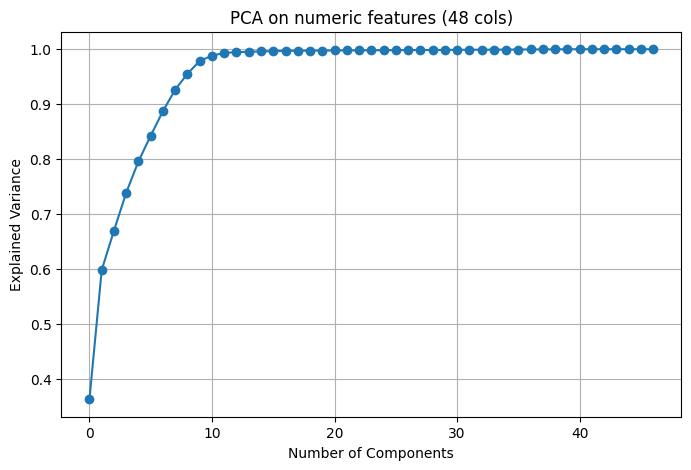

9


In [248]:
plt.figure(figsize=(8,5))
plt.plot(explained, marker='o', label="Cumulative Explained Variance")

plt.xlabel("Number of Components")
plt.ylabel("Explained Variance")

plt.title("PCA on numeric features (48 cols)")
plt.grid(True)
plt.show()

n_components_95 = np.argmax(explained >= 0.95) + 1
print(n_components_95)

In [249]:

pipe = Pipeline([
    ("transform", ct),
    ("pca", PCA(n_components=10)),
    ("svm", SVC(probability=True, class_weight="balanced"))
])
pipe

,steps,"[('transform', ...), ('pca', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('HiD', ...), ('onehot', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [250]:
param_grid = {
    'pca__n_components': [5, 10, 20, 0.95],
    'svm__C': [0.1, 1, 10],
    'svm__gamma': ['scale', 0.01, 0.1],
    'svm__kernel': ['rbf']
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
grid = GridSearchCV(pipe, param_grid, cv=cv, scoring="accuracy", 
                    n_jobs=-1, verbose=2)
grid.fit(X_train, y_train)




Fitting 3 folds for each of 36 candidates, totalling 108 fits


C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
27 fits failed out of a total of 108.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
18 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\Users\ASUS\AppData\Roaming\Python\Python313\site-pack

,estimator,Pipeline(step...ility=True))])
,param_grid,"{'pca__n_components': [5, 10, ...], 'svm__C': [0.1, 1, ...], 'svm__gamma': ['scale', 0.01, ...], 'svm__kernel': ['rbf']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('HiD', ...), ('onehot', ...), ...]"


In [251]:
print("Best params:", grid.best_params_)
print("Best cross-val acc:", grid.best_score_)

Best params: {'pca__n_components': 10, 'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Best cross-val acc: 0.9895651541593949


In [252]:
from sklearn.metrics import accuracy_score

best_pipe = grid.best_estimator_
y_pred = best_pipe.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')
print("Test score:", best_pipe.score(X_test, y_test))

Accuracy: 85.58%
Test score: 0.8557692307692307
